In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Advertising Budget and sales.csv")

# Display the first 5 rows
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# Check the dataset information
print(df.info())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display basic statistics
print("\nDescriptive statistics:")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Missing values:
Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

Descriptive statistics:


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


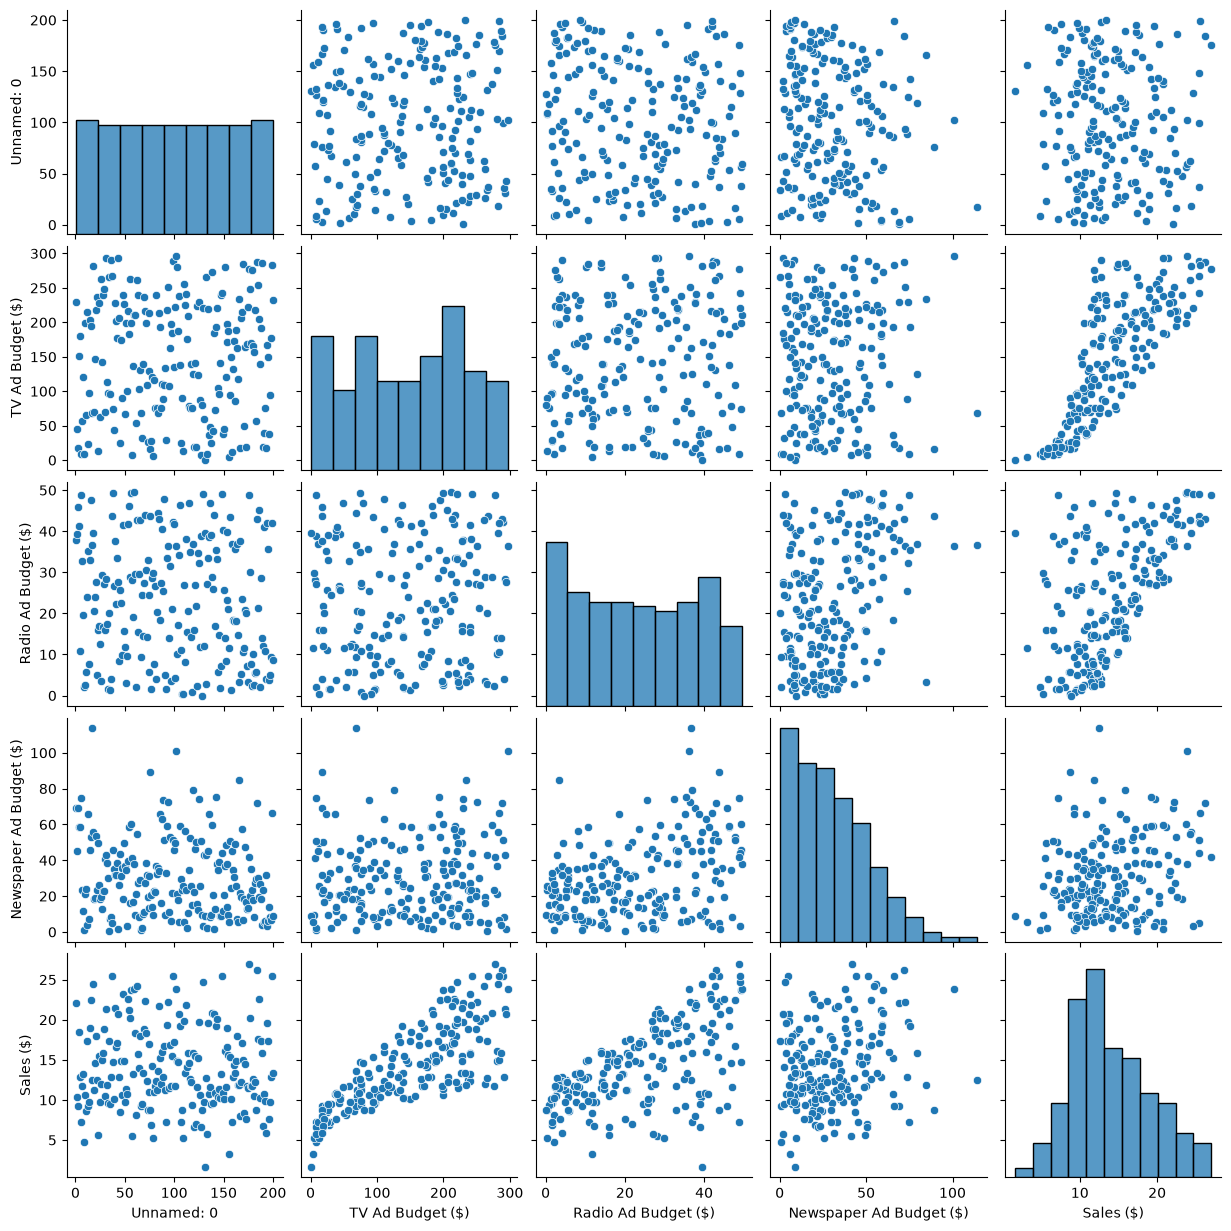

In [4]:
sns.pairplot(df)
plt.show()

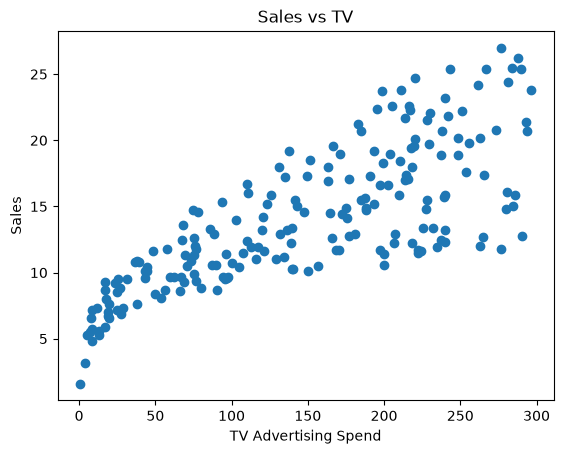

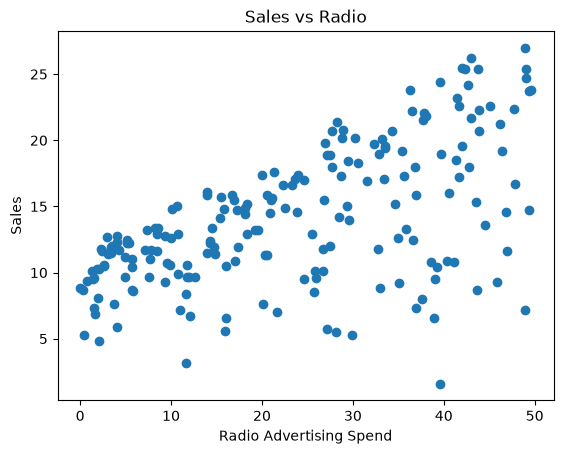

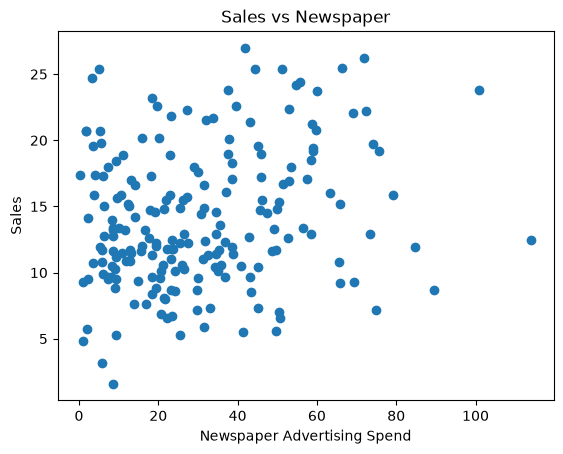

In [11]:
# Sales vs TV
plt.scatter(df["TV Ad Budget ($)"], df["Sales ($)"])
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("Sales vs TV")
plt.show()

# Sales vs Radio
plt.scatter(df["Radio Ad Budget ($)"], df["Sales ($)"])
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.title("Sales vs Radio")
plt.show()

# Sales vs Newspaper
plt.scatter(df["Newspaper Ad Budget ($)"], df["Sales ($)"])
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.title("Sales vs Newspaper")
plt.show()

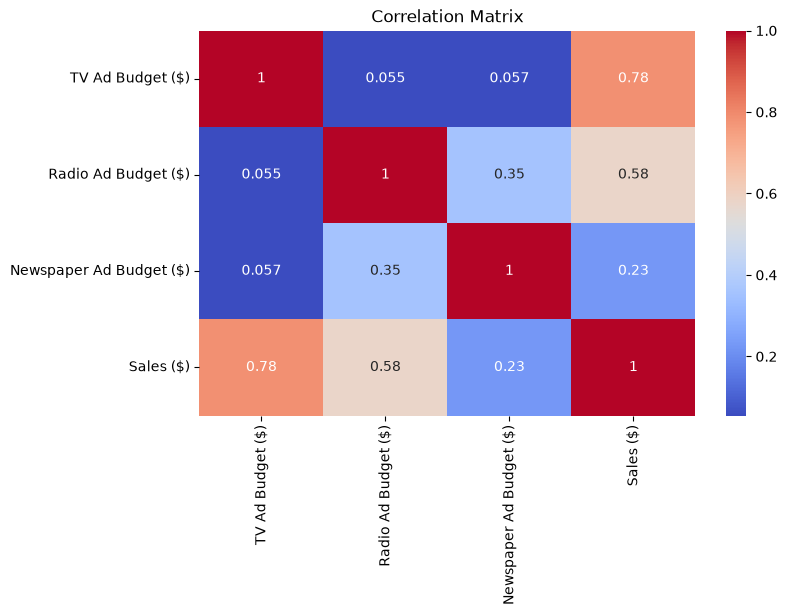

In [12]:
# Select the numerical columns
data = df[[
    "TV Ad Budget ($)",
    "Radio Ad Budget ($)",
    "Newspaper Ad Budget ($)",
    "Sales ($)"
]]

# Create correlation matrix
correlation = data.corr()

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

# Features
X = data[[
    "TV Ad Budget ($)",
    "Radio Ad Budget ($)",
    "Newspaper Ad Budget ($)"
]]

# Target
y = data["Sales ($)"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [14]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred = lr_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Results
MAE: 1.4607567168117603
RMSE: 1.78159966153345
R² Score: 0.899438024100912


In [16]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [17]:
# Make predictions
rf_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE: 0.6203249999999988
RMSE: 0.7687170968568338
R² Score: 0.9812782416450916


In [18]:
print("Model Comparison")
print("-------------------------")
print("Linear Regression R²:", r2)
print("Random Forest R²:", rf_r2)
print()
print("Linear Regression RMSE:", rmse)
print("Random Forest RMSE:", rf_rmse)

Model Comparison
-------------------------
Linear Regression R²: 0.899438024100912
Random Forest R²: 0.9812782416450916

Linear Regression RMSE: 1.78159966153345
Random Forest RMSE: 0.7687170968568338


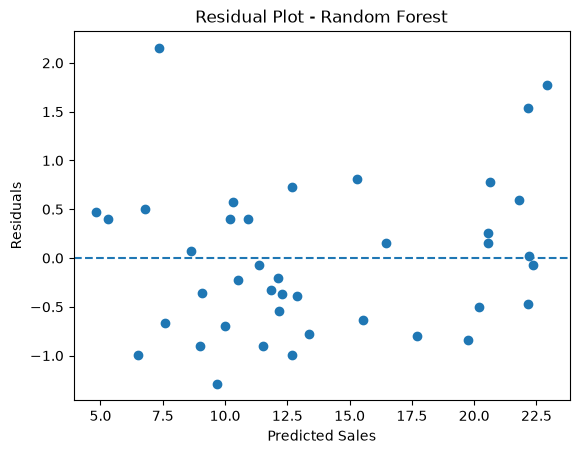

In [19]:
# Calculate residuals
residuals = y_test - rf_pred

# Residual plot
plt.scatter(rf_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")
plt.show()

In [20]:
# Display the impact of each advertising channel
coefficients = pd.DataFrame({
    "Advertising Channel": X.columns,
    "Coefficient": lr_model.coef_
})

print(coefficients)

# Find the channel with the highest coefficient
highest_impact = coefficients.loc[
    coefficients["Coefficient"].idxmax(), "Advertising Channel"
]

print("\nHighest impact advertising channel:", highest_impact)

       Advertising Channel  Coefficient
0         TV Ad Budget ($)     0.044730
1      Radio Ad Budget ($)     0.189195
2  Newspaper Ad Budget ($)     0.002761

Highest impact advertising channel: Radio Ad Budget ($)
